In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [2]:
def load_amazon_data(path, nrows=500_000):
    data = []
    with open(path, 'rt', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= nrows:
                break
            data.append(json.loads(line))
    return pd.DataFrame(data)

In [3]:
# change this line only
df = load_amazon_data(r'D:\VCUBE NOTES\projects\Amazon(RS)\amazon-recsy\data\Musical_Instruments.json.gz')
df.head()

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,image
0,5.0,90,False,"08 9, 2004",AXHY24HWOF184,0470536454,{'Format:': ' Paperback'},Bendy,Crocheting for Dummies by Karen Manthey & Susa...,Terrific Book for Learning the Art of Crochet,1092009600,NaN
1,4.0,2,True,"04 6, 2017",A29OWR79AM796H,0470536454,{'Format:': ' Hardcover'},Amazon Customer,Very helpful...,Four Stars,1491436800,NaN
2,5.0,NaN,True,"03 14, 2017",AUPWU27A7X5F6,0470536454,{'Format:': ' Paperback'},Amazon Customer,EASY TO UNDERSTAND AND A PROMPT SERVICE TOO,Five Stars,1489449600,NaN
3,4.0,NaN,True,"02 14, 2017",A1N69A47D4JO6K,0470536454,{'Format:': ' Paperback'},Christopher Burnett,My girlfriend use quite often,Four Stars,1487030400,NaN
4,5.0,NaN,True,"01 29, 2017",AHTIQUMVCGBFJ,0470536454,{'Format:': ' Paperback'},Amazon Customer,Arrived as described. Very happy.,Very happy.,1485648000,NaN


In [4]:
print(f"Shape: {df.shape}")
print(df.head())

Shape: (500000, 12)
   overall vote  verified   reviewTime      reviewerID        asin  \
0      5.0   90     False   08 9, 2004   AXHY24HWOF184  0470536454   
1      4.0    2      True   04 6, 2017  A29OWR79AM796H  0470536454   
2      5.0  NaN      True  03 14, 2017   AUPWU27A7X5F6  0470536454   
3      4.0  NaN      True  02 14, 2017  A1N69A47D4JO6K  0470536454   
4      5.0  NaN      True  01 29, 2017   AHTIQUMVCGBFJ  0470536454   

                       style         reviewerName  \
0  {'Format:': ' Paperback'}                Bendy   
1  {'Format:': ' Hardcover'}      Amazon Customer   
2  {'Format:': ' Paperback'}      Amazon Customer   
3  {'Format:': ' Paperback'}  Christopher Burnett   
4  {'Format:': ' Paperback'}      Amazon Customer   

                                          reviewText  \
0  Crocheting for Dummies by Karen Manthey & Susa...   
1                                    Very helpful...   
2        EASY TO UNDERSTAND AND A PROMPT SERVICE TOO   
3               

In [5]:
print("Columns:", df.columns.tolist())
print("\nShape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nRating distribution:\n", df['overall'].value_counts())
print("\nUnique users:", df['reviewerID'].nunique())
print("\nUnique products:", df['asin'].nunique())

Columns: ['overall', 'vote', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'image']

Shape: (500000, 12)

Missing values:
 overall                0
vote              413849
verified               0
reviewTime             0
reviewerID             0
asin                   0
style             228801
reviewerName          54
reviewText           189
summary              103
unixReviewTime         0
image             494904
dtype: int64

Rating distribution:
 overall
5.0    331538
4.0     82520
3.0     33516
1.0     32601
2.0     19825
Name: count, dtype: int64

Unique users: 319384

Unique products: 8095


In [6]:
# Keep only essential columns
df = df[['reviewerID', 'asin', 'overall', 'reviewText', 'summary', 'unixReviewTime']]

# Drop rows where reviewText or summary is missing
df = df.dropna(subset=['reviewText', 'summary'])

print("Clean shape:", df.shape)
print(df.head(3))

Clean shape: (499711, 6)
       reviewerID        asin  overall  \
0   AXHY24HWOF184  0470536454      5.0   
1  A29OWR79AM796H  0470536454      4.0   
2   AUPWU27A7X5F6  0470536454      5.0   

                                          reviewText  \
0  Crocheting for Dummies by Karen Manthey & Susa...   
1                                    Very helpful...   
2        EASY TO UNDERSTAND AND A PROMPT SERVICE TOO   

                                         summary  unixReviewTime  
0  Terrific Book for Learning the Art of Crochet      1092009600  
1                                     Four Stars      1491436800  
2                                     Five Stars      1489449600  


In [7]:
df.columns = ['user_id', 'product_id', 'rating', 'review_text', 'summary', 'timestamp']
print(df.dtypes)

user_id         object
product_id      object
rating         float64
review_text     object
summary         object
timestamp        int64
dtype: object


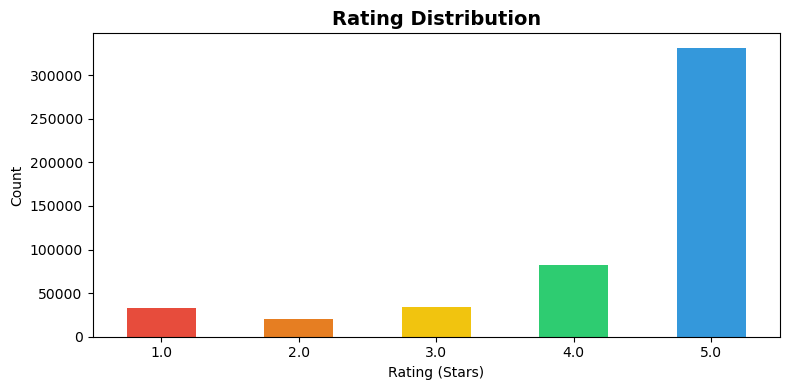

5-star %: 66.3 %


In [8]:
plt.figure(figsize=(8, 4))
df['rating'].value_counts().sort_index().plot(kind='bar', color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
plt.title('Rating Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Rating (Stars)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/rating_distribution.png')
plt.show()
print("5-star %:", round(df[df['rating']==5].shape[0] / df.shape[0] * 100, 1), "%")

User activity stats:
count    319201.000000
mean          1.565506
std           1.566379
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         167.000000
Name: review_count, dtype: float64


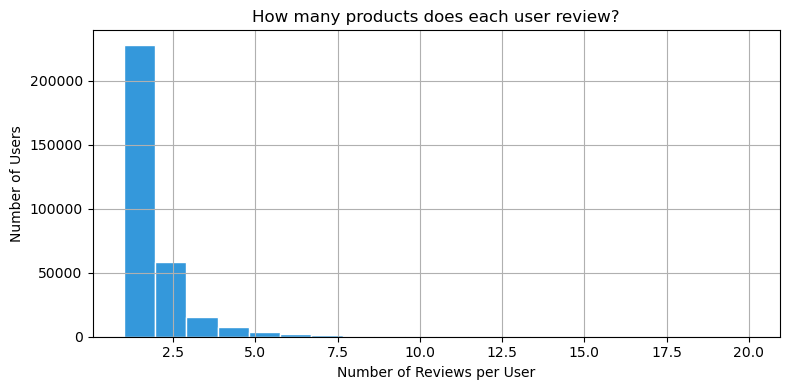

In [9]:
user_activity = df.groupby('user_id')['product_id'].count().reset_index()
user_activity.columns = ['user_id', 'review_count']

print("User activity stats:")
print(user_activity['review_count'].describe())

plt.figure(figsize=(8, 4))
user_activity[user_activity['review_count'] <= 20]['review_count'].hist(bins=20, color='#3498db', edgecolor='white')
plt.title('How many products does each user review?')
plt.xlabel('Number of Reviews per User')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

In [10]:
product_popularity = df.groupby('product_id')['user_id'].count().reset_index()
product_popularity.columns = ['product_id', 'review_count']

print("Product popularity stats:")
print(product_popularity['review_count'].describe())

# Top 10 most reviewed products
print("\nTop 10 most reviewed products:")
print(product_popularity.sort_values('review_count', ascending=False).head(10))

Product popularity stats:
count    8095.000000
mean       61.730821
std       193.254102
min         1.000000
25%         6.000000
50%        16.000000
75%        48.000000
max      5064.000000
Name: review_count, dtype: float64

Top 10 most reviewed products:
      product_id  review_count
4871  B000VSM4MS          5064
4991  B000XI6O2W          3902
869   B0002E1NNC          3602
874   B0002E1NWI          3602
2619  B0006NDF8A          3163
7006  B002026DR0          3105
2839  B0007Y09VO          3088
2004  B0002H0A3S          3086
2519  B00063678K          2767
4849  B000VJJQUU          2622


In [11]:
# Users with less than 5 reviews and products with less than 5 reviews
# create a "cold start" problem — our model can't learn from them
# This is what every real RecSys engineer does first

MIN_USER_REVIEWS = 5
MIN_PRODUCT_REVIEWS = 5

# Filter users
user_counts = df['user_id'].value_counts()
df = df[df['user_id'].isin(user_counts[user_counts >= MIN_USER_REVIEWS].index)]

# Filter products
product_counts = df['product_id'].value_counts()
df = df[df['product_id'].isin(product_counts[product_counts >= MIN_PRODUCT_REVIEWS].index)]

print(f"After filtering:")
print(f"Rows: {df.shape[0]:,}")
print(f"Unique users: {df['user_id'].nunique():,}")
print(f"Unique products: {df['product_id'].nunique():,}")

# Save clean data
df.to_csv('../data/clean_ratings.csv', index=False)
print("\n✅ Saved to data/clean_ratings.csv")

After filtering:
Rows: 72,696
Unique users: 10,327
Unique products: 2,717

✅ Saved to data/clean_ratings.csv
